
## LangGraph with external tools



In [ ]:
!pip install langgraph langsmith langchain langchain_groq langchain_community

In [39]:
!pip install arxiv wikipedia

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

In [ ]:
from langchain_core.tools import tool

@tool
def wikipedia_search(query: str) -> str:
    '''wikipedia tool'''
    from langchain_community.utilities import WikipediaAPIWrapper
    return str(WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=300).run(query))

@tool
def arxiv_search(query: str) -> str:
    '''arxiv tool'''
    from langchain_community.utilities import ArxivAPIWrapper
    return str(ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=300).run(query))

In [3]:
wikipedia_search.invoke("Who is Elon Musk")

'Page: Errol Musk\nSummary: Errol Graham Musk (born 25 May 1946) is a South African businessman, politician, and the patriarch of the Musk family. He was an Independent member of Pretoria City Council from 1972 to 1980 and then as a member of Progressive Federal Party from 1980 to 1983. As a businessm'

In [4]:
arxiv_search.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their mult'

In [5]:
tools=[wikipedia_search]

In [6]:
## Langgraph Application
from langgraph.graph.message import add_messages
class State(TypedDict):
  messages:Annotated[list,add_messages]

In [7]:
from langgraph.graph import StateGraph,START,END

In [8]:
graph_builder= StateGraph(State)


In [9]:
from langchain_groq import ChatGroq

In [10]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API")

In [11]:
llm=ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x78bb97370b30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x78bb96550a10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [12]:
llm_with_tools=llm.bind_tools(tools=tools)

In [13]:
def chatbot(state:State):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [14]:
from langgraph.prebuilt import ToolNode,tools_condition

In [15]:
graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START,"chatbot")



In [16]:
graph=graph_builder.compile()

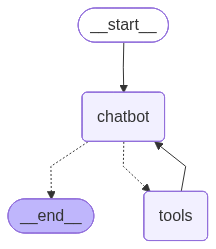

In [17]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [18]:
user_input="Hi there!, My name is John"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there!, My name is John
================================== Ai Message ==================================

It's nice to meet you, John. Is there something I can help you with or would you like to chat?


In [20]:
user_input="What is physics?"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

What is physics?
================================== Ai Message ==================================
Tool Calls:
  wikipedia_search (x4xzk7k6c)
 Call ID: x4xzk7k6c
  Args:
    query: physics
================================= Tool Message =================================
Name: wikipedia_search

Page: Physics
Summary: Physics is the scientific study of matter, its fundamental constituents, its motion and behavior through space and time, and the related entities of energy and force. It is one of the most fundamental scientific disciplines. A scientist who specializes in the field of physics 
================================== Ai Message ==================================

Physics is the scientific study of matter, its fundamental constituents, its motion and behavior through space and time, and the related entities of energy and force. It is one of the most fundamental scientific disciplines. A scientist who s